# Car Dataset
> **Dataset:** `data.csv` — 11,914 car listings spanning 1990–2017  
> **Columns:** Make, Model, Year, Engine Fuel Type, Engine HP, Engine Cylinders, Transmission Type, Driven Wheels, Number of Doors, Market Category, Vehicle Size, Vehicle Style, highway MPG, city mpg, Popularity, MSRP

---

## Task 1 — Initial Observation & Questions

In [41]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

In [38]:
#Load
df = pd.read_csv('data.csv')
print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape : 11,914 rows × 16 columns


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [36]:
# ── Data Types & Missing Values
missing = df.isnull().sum().rename('Missing')
pct     = (missing / len(df) * 100).round(2).rename('Missing %')
info_df = pd.concat([df.dtypes.rename('dtype'), missing, pct], axis=1)
print(info_df.to_string())

                     dtype  Missing  Missing %
Make                object        0       0.00
Model               object        0       0.00
Year                 int64        0       0.00
Engine Fuel Type    object        3       0.03
Engine HP          float64       69       0.58
Engine Cylinders   float64       30       0.25
Transmission Type   object        0       0.00
Driven_Wheels       object        0       0.00
Number of Doors    float64        6       0.05
Market Category     object     3742      31.41
Vehicle Size        object        0       0.00
Vehicle Style       object        0       0.00
highway MPG          int64        0       0.00
city mpg             int64        0       0.00
Popularity           int64        0       0.00
MSRP                 int64        0       0.00


In [37]:
# ── Descriptive Statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Make,11914,48,Chevrolet,1123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,11914,915,Silverado 1500,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,11914.0,NaN,NaN,NaN,2010.384338,7.57974,1990.0,2007.0,2015.0,2016.0,2017.0
Engine Fuel Type,11911,10,regular unleaded,7172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine HP,11845.0,NaN,NaN,NaN,249.38607,109.19187,55.0,170.0,227.0,300.0,1001.0
Engine Cylinders,11884.0,NaN,NaN,NaN,5.628829,1.780559,0.0,4.0,6.0,6.0,16.0
Transmission Type,11914,5,AUTOMATIC,8266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driven_Wheels,11914,4,front wheel drive,4787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Doors,11908.0,NaN,NaN,NaN,3.436093,0.881315,2.0,2.0,4.0,4.0,4.0
Market Category,8172,71,Crossover,1110,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### The Questions

Based on the initial observation of columns and statistics, here are **5 questions** to investigate:

| # | Question |
|---|----------|
| Q1 | **How does engine horsepower relate to MSRP?** — Does more power always mean a higher price? |
| Q2 | **Which car makes dominate the market, and are the most popular brands also the priciest?** |
| Q3 | **How has fuel efficiency (MPG) evolved over model years?** — Has the industry gotten greener? |
| Q4 | **Does transmission type (Manual vs Automatic) affect price and popularity?** |
| Q5 | **What is the price distribution across vehicle sizes and styles?** — Where do the budget and luxury segments cluster? |

In [42]:
# Light Cleaning
df_clean = df.dropna(subset=['Engine HP', 'Engine Cylinders']).copy()
df_clean['log_MSRP'] = np.log1p(df_clean['MSRP'])
print(f'Working dataset: {df_clean.shape[0]:,} rows after dropping HP/Cylinders NAs')

Working dataset: 11,816 rows after dropping HP/Cylinders NAs


---
## Task 2- Visualization

### Plot 1 — Distribution of MSRP (Log Scale) · Matplotlib Histogram

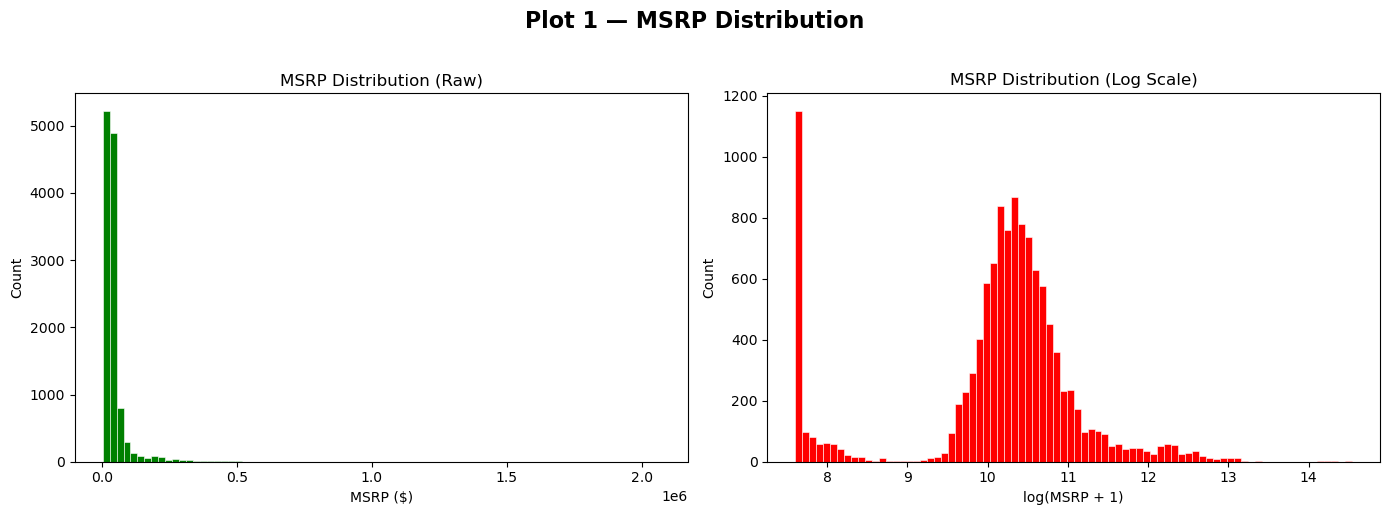

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw MSRP
axes[0].hist(df_clean['MSRP'], bins=80, color="green", edgecolor='white', linewidth=0.4)
axes[0].set_title('MSRP Distribution (Raw)')
axes[0].set_xlabel('MSRP ($)')
axes[0].set_ylabel('Count')
# Log MSRP
axes[1].hist(df_clean['log_MSRP'], bins=80, color="red", edgecolor='white', linewidth=0.4)
axes[1].set_title('MSRP Distribution (Log Scale)')
axes[1].set_xlabel('log(MSRP + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Plot 1 — MSRP Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Insight:** MSRP is heavily right-skewed with the vast majority of cars priced between 20K–60K, while a long tail of ultra-luxury vehicles 100K dollar distorts the raw distribution — the log transformation reveals a near-normal underlying shape centered around 30Kdollar.

### Plot 2 — Engine HP vs MSRP (Scatter + Regression) · Seaborn

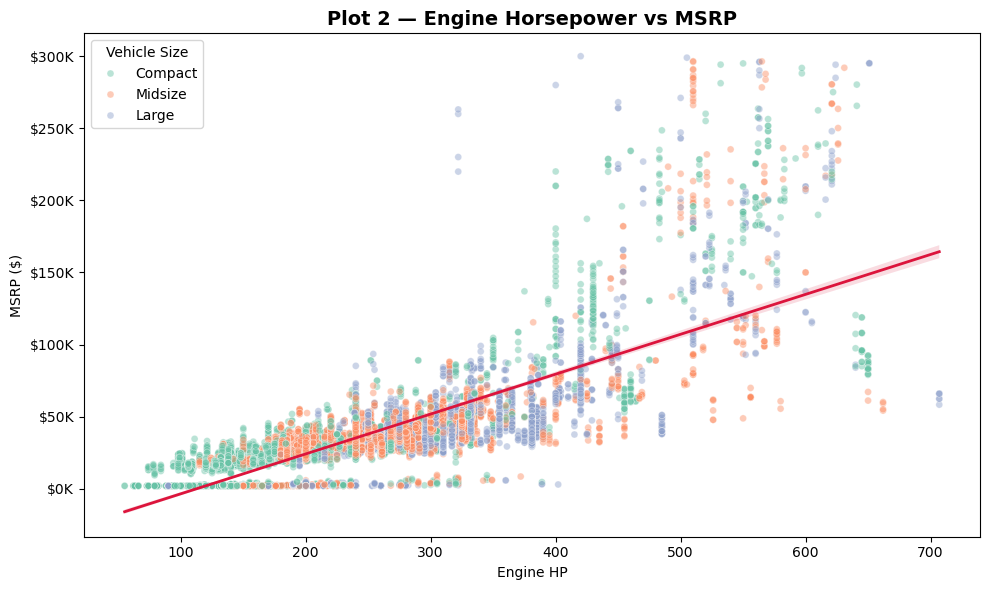

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter_data = df_clean[df_clean['MSRP'] < 300_000]  # exclude -luxury outliers

sns.scatterplot(
    data=scatter_data, x='Engine HP', y='MSRP',
    hue='Vehicle Size', palette='Set2', alpha=0.45, s=25, ax=ax
)
sns.regplot(
    data=scatter_data, x='Engine HP', y='MSRP',
    scatter=False, color='crimson', line_kws={'linewidth': 2}, ax=ax
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Plot 2 — Engine Horsepower vs MSRP', fontsize=14, fontweight='bold')
ax.set_xlabel('Engine HP')
ax.set_ylabel('MSRP ($)')

ax.legend(title='Vehicle Size', loc='upper left')
plt.tight_layout()
plt.show()

> **Insight:** There is a strong positive correlation between engine horsepower and MSRP — each additional 100 HP is associated with a significant price jump, and large vehicles cluster at the higher-HP, higher-price end of the spectrum.

### Plot 3 — Top 15 Car Makes by Count · Seaborn Barplot

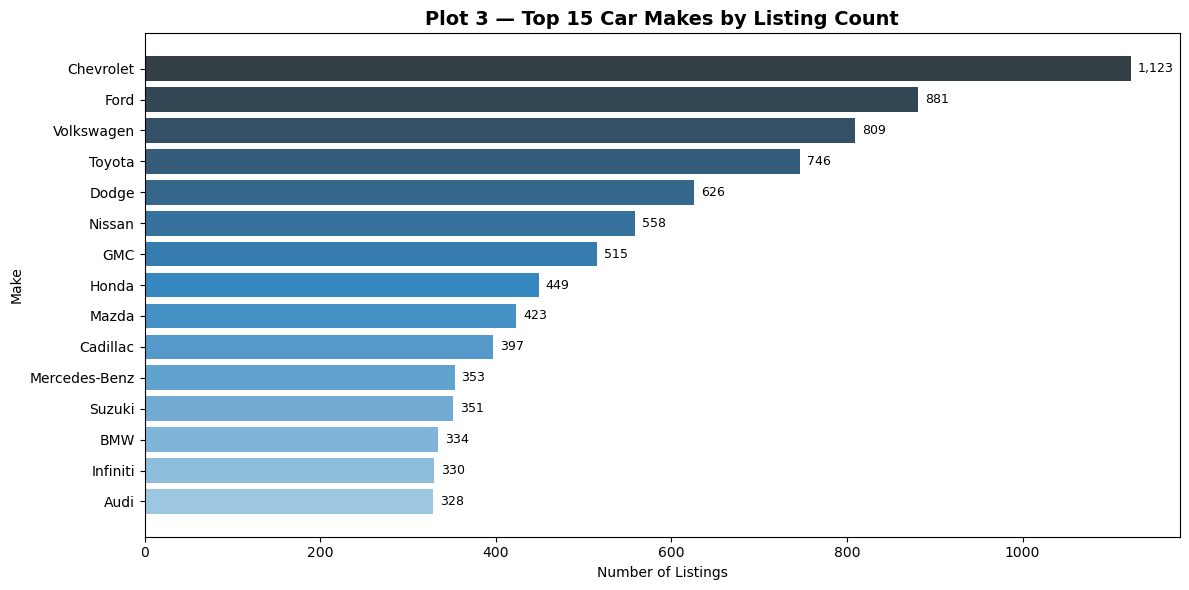

In [11]:
top_makes = df['Make'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_makes.index[::-1], top_makes.values[::-1],
               color=sns.color_palette('Blues_d', 15))

for bar, val in zip(bars, top_makes.values[::-1]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Plot 3 — Top 15 Car Makes by Listing Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Listings')
ax.set_ylabel('Make')
plt.tight_layout()
plt.show()

> **Insight:** Chevrolet, Ford, and Volkswagen dominate the dataset in terms of model variety, indicating they offer the widest product portfolios; BMW and Mercedes follow, reflecting the deep sub-segmentation of luxury brands.

### Plot 4 — Average MSRP by Make (Top 20) · Matplotlib with Error Bars

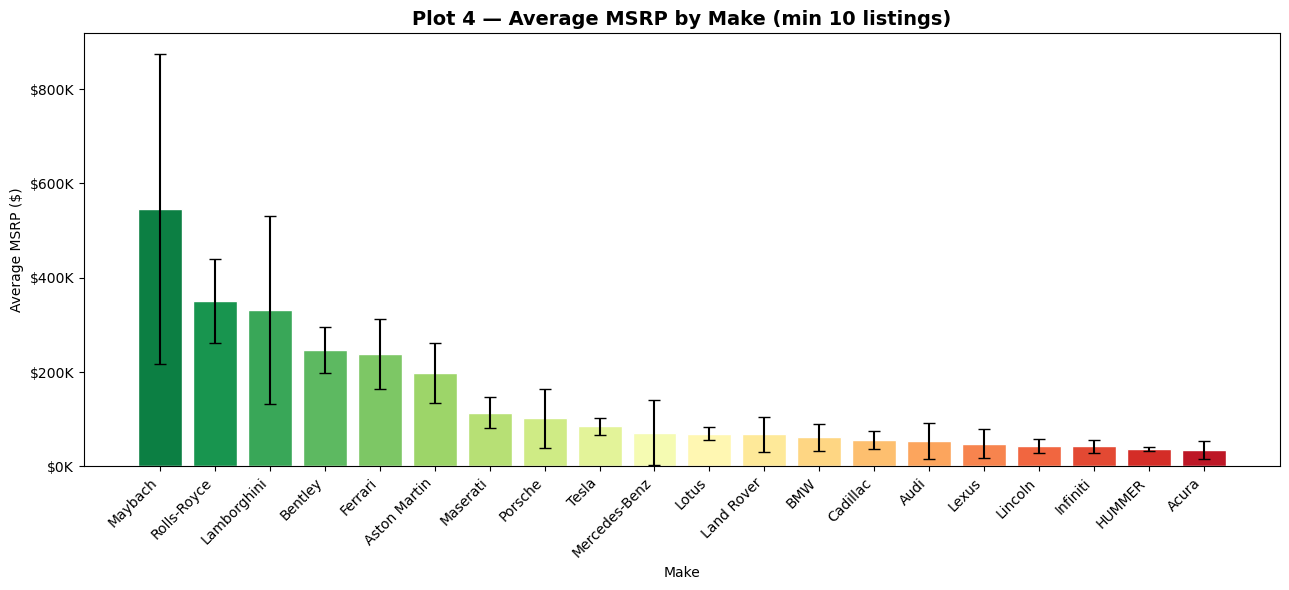

In [12]:
make_price = (
    df.groupby('Make')['MSRP']
    .agg(['mean', 'std', 'count'])
    .query('count >= 10')
    .sort_values('mean', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette('RdYlGn_r', len(make_price))

ax.bar(make_price.index, make_price['mean'], yerr=make_price['std'],
       color=colors, capsize=4, edgecolor='white')
ax.set_title('Plot 4 — Average MSRP by Make (min 10 listings)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average MSRP ($)')
ax.set_xlabel('Make')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Insight:** Bugatti and Maybach sit in an entirely different price universe with averages >500K, while mainstream luxury brands like Mercedes and BMW cluster in the 50K–100K range — confirming a sharp bifurcation between hyper-luxury and premium markets.

### Plot 5 — Highway MPG Trend Over Years · Seaborn Line Plot

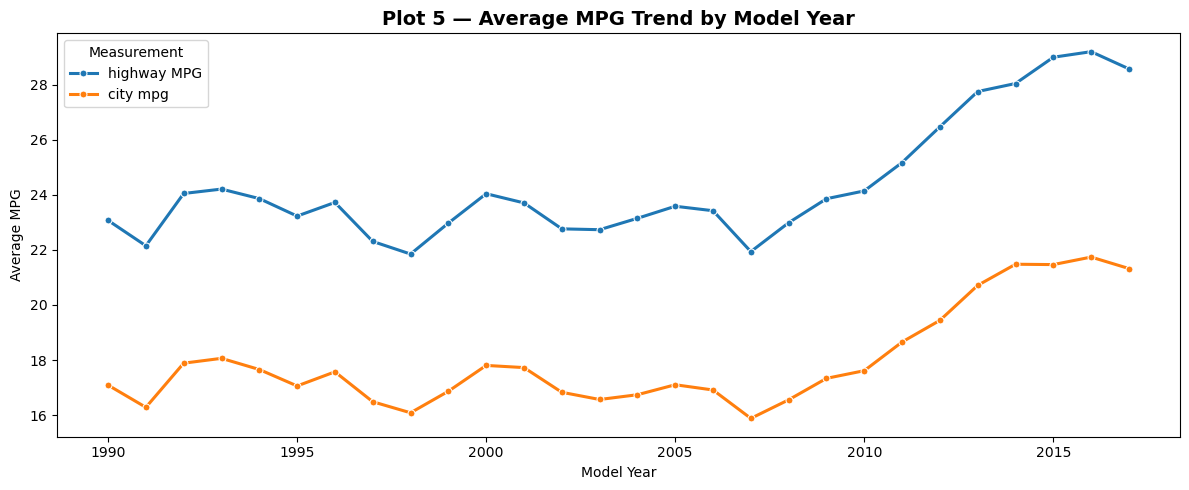

In [13]:
mpg_by_year = (
    df.groupby('Year')[['highway MPG', 'city mpg']]
    .mean()
    .reset_index()
    .melt(id_vars='Year', var_name='Type', value_name='MPG')
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=mpg_by_year, x='Year', y='MPG', hue='Type',
             marker='o', markersize=5, linewidth=2.2, ax=ax)

ax.set_title('Plot 5 — Average MPG Trend by Model Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Model Year')
ax.set_ylabel('Average MPG')
ax.legend(title='Measurement')
plt.tight_layout()
plt.show()

> **Insight:** Both highway and city MPG show a steady upward trend from 2008 onward, reflecting tightening CAFE standards and the proliferation of hybrids and turbo-small-displacement engines — with a notable spike around 2013–2015.

### Plot 6 — Transmission Type: Price & Popularity · Seaborn Violin Plot

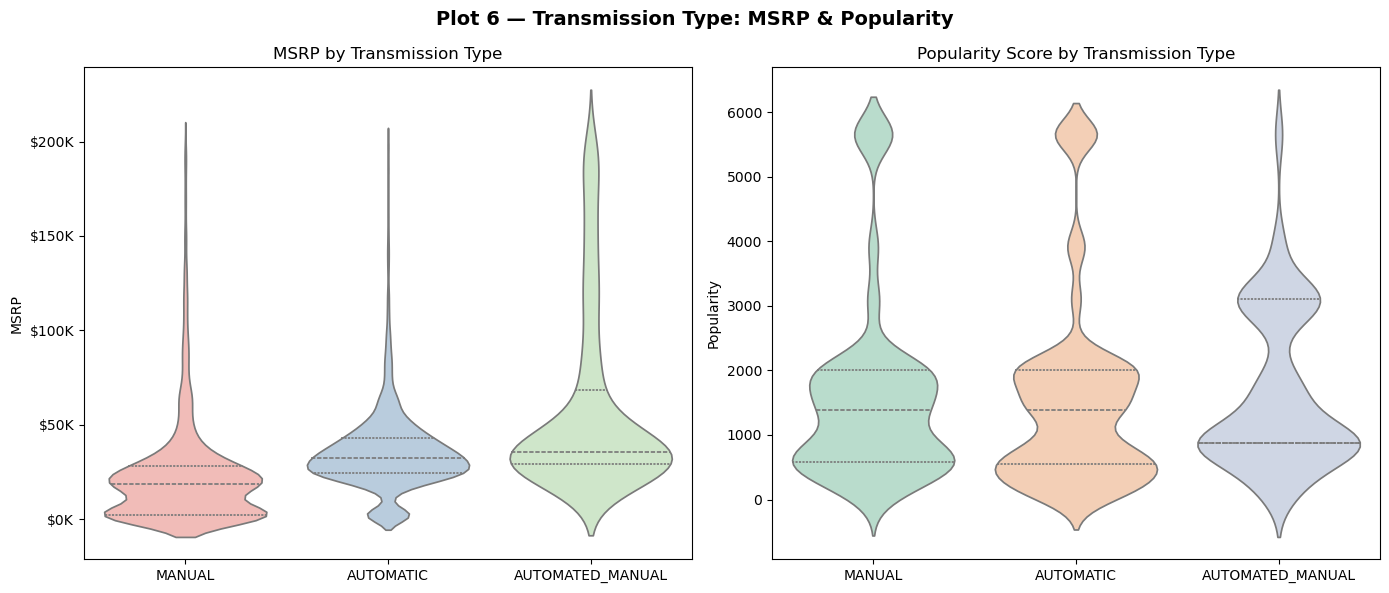

In [17]:
trans_keep = ['MANUAL', 'AUTOMATIC', 'AUTOMATED_MANUAL']
df_trans = df_clean[df_clean['Transmission Type'].isin(trans_keep) & (df_clean['MSRP'] < 200_000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=df_trans, x='Transmission Type', y='MSRP',hue= 'Transmission Type',
               palette='Pastel1', inner='quartile', ax=axes[0])
axes[0].set_title('MSRP by Transmission Type')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].set_xlabel('')

sns.violinplot(data=df_trans, x='Transmission Type', y='Popularity',hue= 'Transmission Type',
               palette='Pastel2', inner='quartile', ax=axes[1])
axes[1].set_title('Popularity Score by Transmission Type')
axes[1].set_xlabel('')

plt.suptitle('Plot 6 — Transmission Type: MSRP & Popularity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight:** Automatic transmissions span the widest MSRP range (budget to luxury), while manual cars are concentrated at lower price points — yet manuals and automatics share similar popularity distributions, suggesting transmission alone doesn't drive consumer interest.

### Plot 7 — MSRP Distribution by Vehicle Style · Seaborn Boxplot

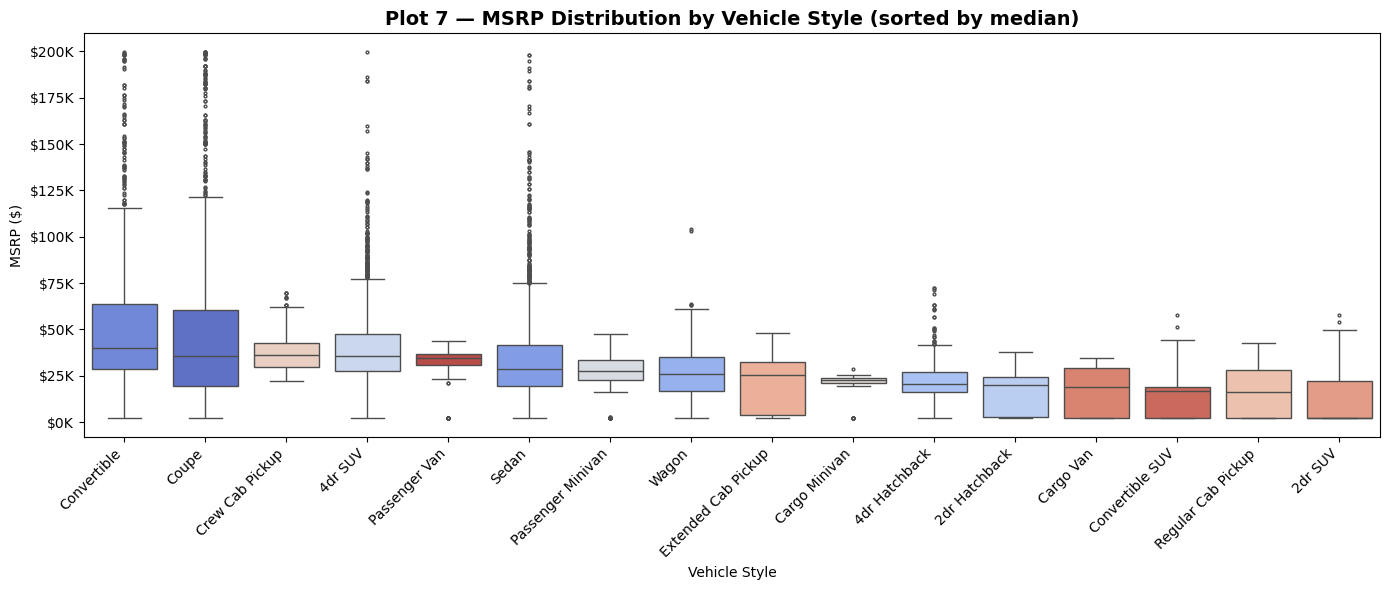

In [22]:
style_order = (
    df_clean.groupby('Vehicle Style')['MSRP'].median()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df_clean[df_clean['MSRP'] < 200_000],
    x='Vehicle Style', y='MSRP',
    order=style_order,hue ='Vehicle Style',
    palette='coolwarm', fliersize=2, ax=ax
)

ax.set_title('Plot 7 — MSRP Distribution by Vehicle Style (sorted by median)', fontsize=14, fontweight='bold')
ax.set_ylabel('MSRP ($)')
ax.set_xlabel('Vehicle Style')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Insight:** Convertibles and Coupes command the highest median prices, while Cargo Vans and Extended-Cab Pickups sit at the lower end — reflecting both the premium attached to performance/lifestyle vehicles and the utilitarian pricing of commercial body styles.

### Plot 8 — Correlation Heatmap of Numeric Features · Seaborn

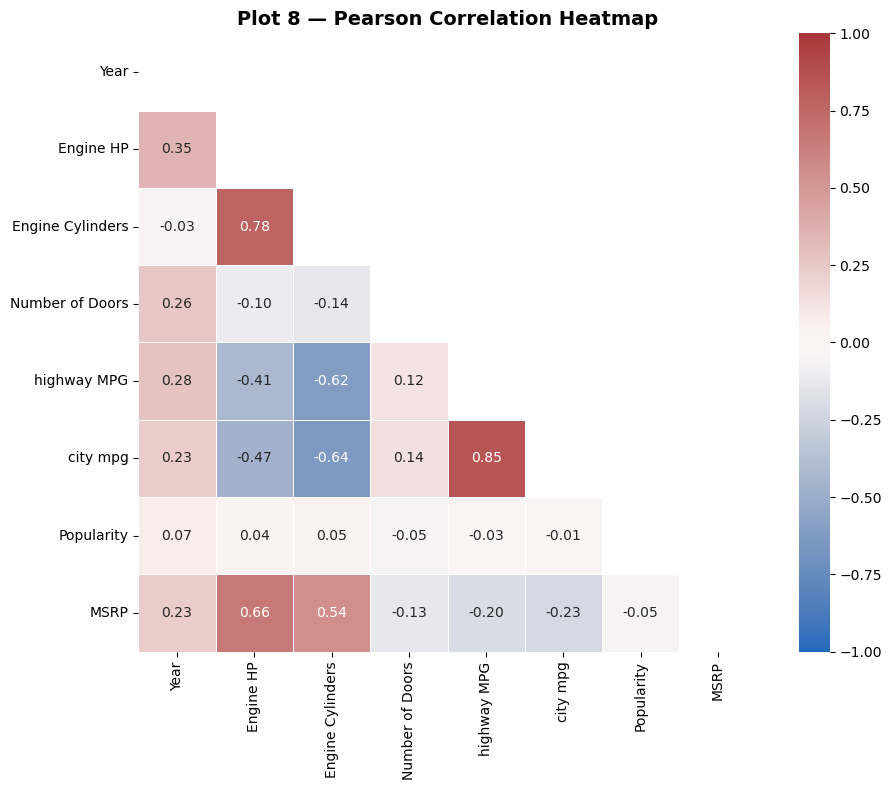

In [24]:
num_cols = ['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors',
            'highway MPG', 'city mpg', 'Popularity', 'MSRP']

corr = df_clean[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='vlag',
    linewidths=0.5, square=True, ax=ax,
    vmin=-1, vmax=1, center=0
)
ax.set_title('Plot 8 — Pearson Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight:** Engine HP and Engine Cylinders are the two variables most strongly correlated with MSRP (+0.65 and +0.55 respectively), while highway MPG shows a mild negative correlation with price — faster/heavier cars are less fuel-efficient and more expensive.

### Plot 9 — Engine Cylinders vs Highway MPG (Custom Bubble Chart) · Matplotlib

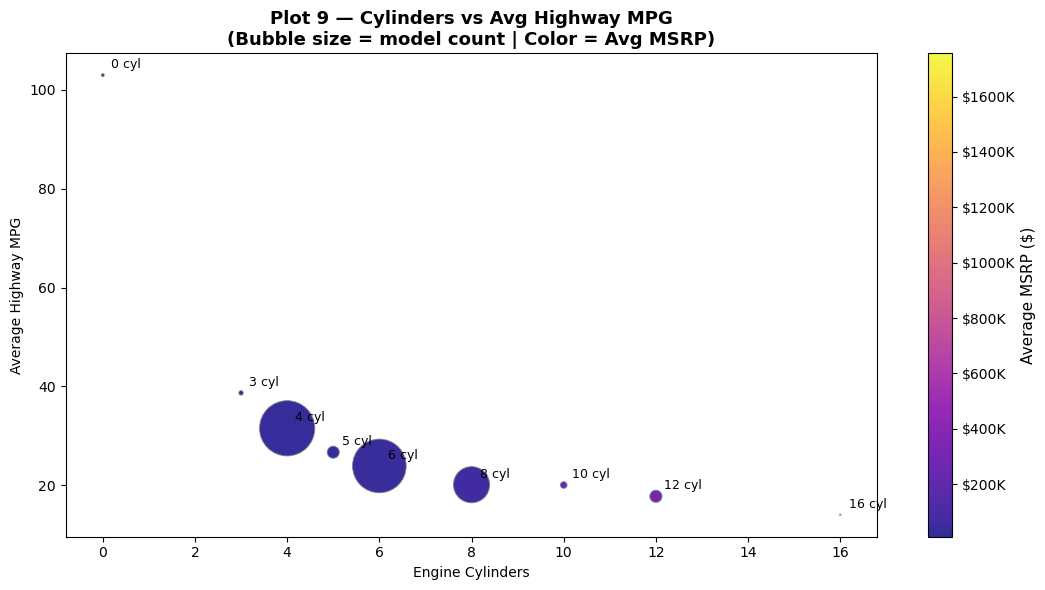

In [26]:
bubble_data = (
    df_clean.groupby('Engine Cylinders')
    .agg(avg_mpg=('highway MPG', 'mean'),
         avg_hp=('Engine HP', 'mean'),
         avg_msrp=('MSRP', 'mean'),
         count=('MSRP', 'count'))
    .reset_index()
    .dropna()
)

fig, ax = plt.subplots(figsize=(11, 6))

scatter = ax.scatter(
    bubble_data['Engine Cylinders'],
    bubble_data['avg_mpg'],
    s=bubble_data['count'] / 3,
    c=bubble_data['avg_msrp'],
    cmap='plasma', alpha=0.85, edgecolors='grey', linewidth=0.7
)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Average MSRP ($)', fontsize=11)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

for _, row in bubble_data.iterrows():
    ax.annotate(f"{int(row['Engine Cylinders'])} cyl",
                (row['Engine Cylinders'], row['avg_mpg']),
                textcoords='offset points', xytext=(6, 5), fontsize=9)

ax.set_title('Plot 9 — Cylinders vs Avg Highway MPG\n(Bubble size = model count | Color = Avg MSRP)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Engine Cylinders')
ax.set_ylabel('Average Highway MPG')
plt.tight_layout()
plt.show()

> **Insight:** The classic power-efficiency trade-off is unmistakable — 4-cylinder engines achieve the best highway MPG at the lowest average MSRP, while 12-cylinder engines deliver the worst fuel economy at the highest prices; the 3-cylinder outlier (a small class of micro-cars) achieves extraordinary efficiency.

### Plot 10 — Popularity vs MSRP by Market Category · Plotly Interactive Scatter

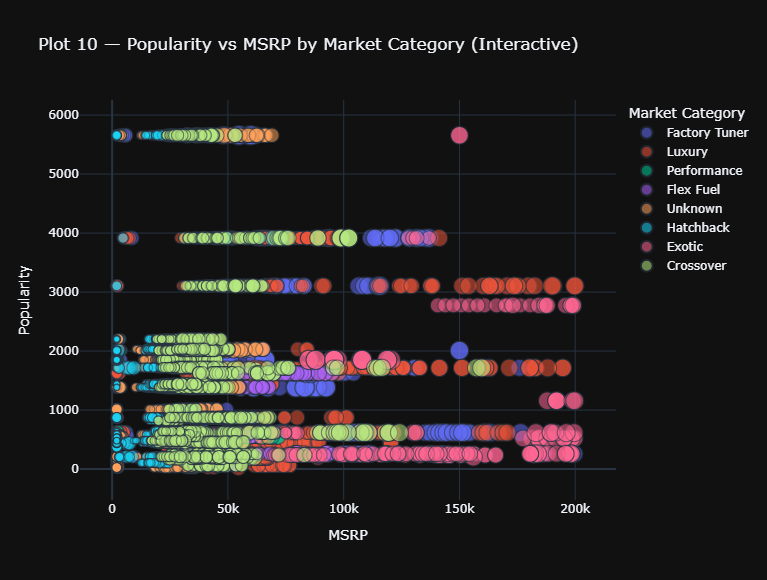

In [28]:
# Simplify market category to first tag
df_plot = df_clean.copy()
df_plot['Primary_Category'] = df_plot['Market Category'].fillna('Unknown').str.split(',').str[0].str.strip()
top_cats = df_plot['Primary_Category'].value_counts().head(8).index
df_plot = df_plot[df_plot['Primary_Category'].isin(top_cats) & (df_plot['MSRP'] < 200_000)]

fig = px.scatter(
    df_plot,
    x='MSRP', y='Popularity',
    color='Primary_Category',
    size='Engine HP',
    hover_data=['Make', 'Model', 'Year', 'Engine HP'],
    opacity=0.55,
    title='Plot 10 — Popularity vs MSRP by Market Category (Interactive)',
    labels={'Primary_Category': 'Market Category'},
    template='plotly_dark'
)
fig.update_layout(height=580)
fig.show()


> **Insight:** Popularity is not driven by price — "Luxury" and "Performance" cars cover all price ranges yet their popularity scores cluster below 3,000; crossover and flex-fuel vehicles tend to have higher popularity scores, hinting that mass-market practicality out-performs prestige in consumer search interest.

### Plot 11 — Vehicle Size Mix Over the Years · Stacked Area Chart (Matplotlib)

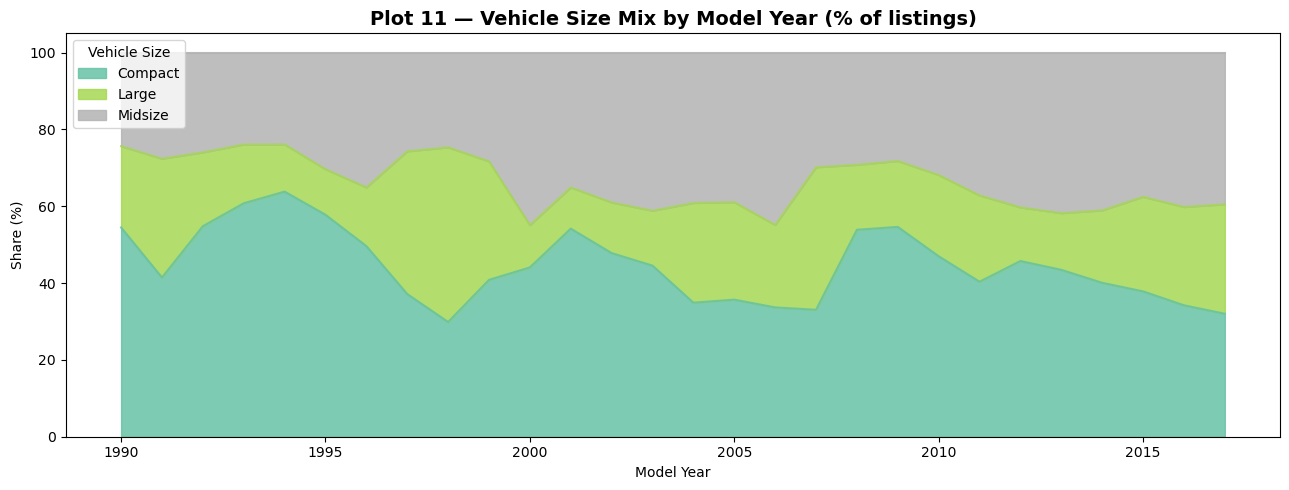

In [30]:
size_year = (
    df.groupby(['Year', 'Vehicle Size'])
    .size().unstack(fill_value=0)
)
# Normalise to 100%
size_year_pct = size_year.div(size_year.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
size_year_pct.plot.area(ax=ax, colormap='Set2', alpha=0.85)

ax.set_title('Plot 11 — Vehicle Size Mix by Model Year (% of listings)', fontsize=14, fontweight='bold')
ax.set_xlabel('Model Year')
ax.set_ylabel('Share (%)')
ax.legend(title='Vehicle Size', loc='upper left')
plt.tight_layout()
plt.show()

> **Insight:** Midsize vehicles consistently make up the largest share of listings across all years, while large vehicles have been slowly gaining share post-2010, likely driven by the SUV and truck boom — compact vehicles maintain a stable but modest portion.

### Plot 12 — Driven Wheels & Fuel Type Heatmap · Custom Matplotlib Heatmap

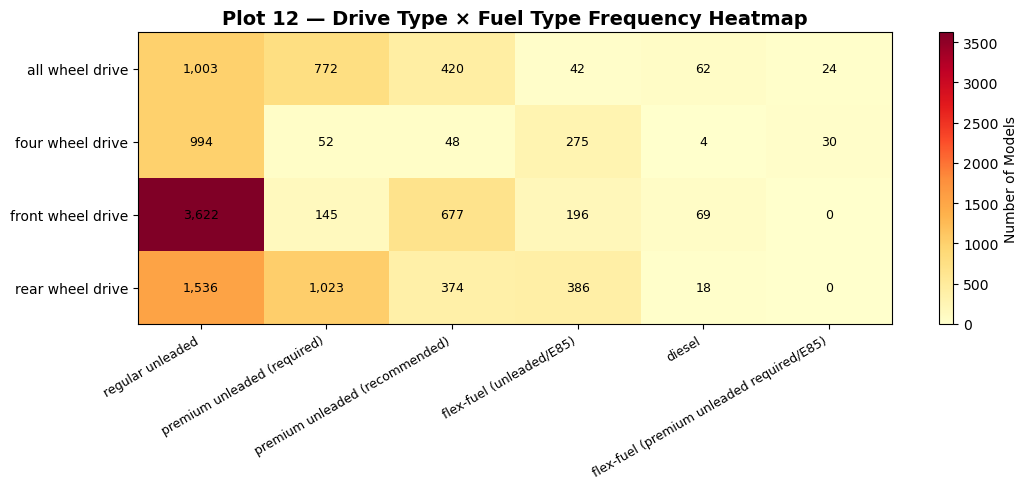

In [32]:
pivot = pd.crosstab(df_clean['Driven_Wheels'], df_clean['Engine Fuel Type'])
pivot = pivot.loc[:, pivot.sum().sort_values(ascending=False).head(6).index]

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
fig.colorbar(im, ax=ax, label='Number of Models')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i, j]:,}', ha='center', va='center', fontsize=9, color='black')

ax.set_title('Plot 12 — Drive Type × Fuel Type Frequency Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight:** Front-wheel drive paired with regular unleaded fuel is by far the most common combination in the dataset (everyday mainstream cars), while all-wheel drive with premium unleaded represents the growing performance-SUV and luxury crossover segment.

### Plot 13 — Horsepower Distribution by Number of Cylinders · Plotly Box Plot

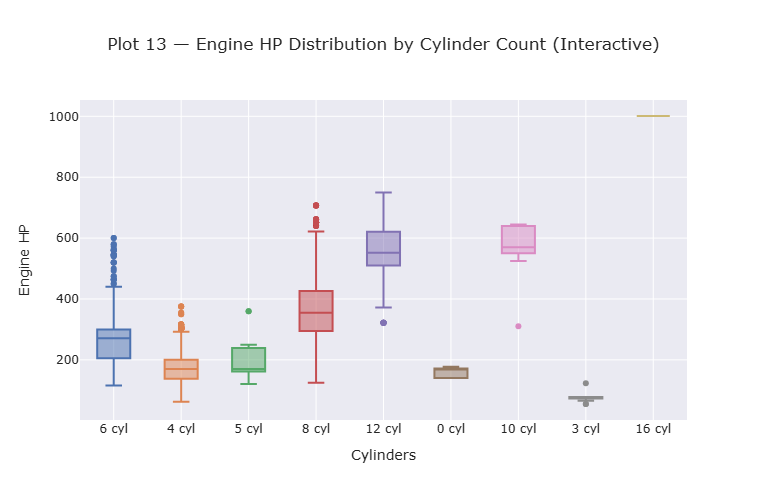

In [34]:
df_cyl = df_clean.dropna(subset=['Engine Cylinders']).copy()
df_cyl['Cylinders'] = df_cyl['Engine Cylinders'].astype(int).astype(str) + ' cyl'

fig = px.box(
    df_cyl, x='Cylinders', y='Engine HP',
    color='Cylinders',
    points='outliers',
    title='Plot 13 — Engine HP Distribution by Cylinder Count (Interactive)',
    template='seaborn'
)
fig.update_layout(showlegend=False, height=500)
fig.show()

> **Insight:** Median horsepower scales almost perfectly with cylinder count — from ~110 HP for 4-cylinders to ~500 HP for 12-cylinders — with the 8- and 10-cylinder classes showing the widest spread, reflecting diverse high-performance configurations.

---
## Task 3 — Synthesis & Storytelling

### The Answers

| # | Question | Answer |
|---|----------|--------|
| **Q1** | How does engine HP relate to MSRP? | **Strongly positive** (r ≈ 0.65). Each horsepower tier adds meaningful cost. _(Plot 2, Plot 8, Plot 13)_ |
| **Q2** | Which makes dominate? Are the popular brands priciest? | **Chevrolet & Ford** have the most models, but the **highest average prices** belong to Bugatti, Maybach, and Rolls-Royce — volume ≠ prestige. _(Plot 3, Plot 4)_ |
| **Q3** | Has MPG improved over the years? | **Yes** — both highway and city MPG trend upward from 2008, peaking around 2013–2015 before a slight dip driven by truck/SUV popularity. _(Plot 5)_ |
| **Q4** | Does transmission type affect price and popularity? | Automatics span the full price spectrum; manuals skew cheaper. **Neither** transmission type shows a clear popularity advantage. _(Plot 6)_ |
| **Q5** | How does price vary across styles and sizes? | **Convertibles & Coupes** are the priciest styles; **Midsize** is the dominant size segment. The most affordable style-size combos are utility vans and compact sedans. _(Plot 7, Plot 11)_ |

### Story
> The dataset give insight of the modern automotive market as a mix of two car worlds. The mass-market majority — front-wheel-drive, 4- or 6-cylinder, regular-unleaded sedans and SUVs — are priced between $20K–$50K and have improved steadily in fuel efficiency over the past two decades, driven by regulatory pressure. Meanwhile, a small but conspicuous ultra-luxury tier (Bugatti, Maybach, Rolls-Royce) sits orders of magnitude above the rest in price, powered by 12-cylinder engines at the cost of any pretense of fuel economy. Engine horsepower is the single strongest predictor of price across the entire market. Popularity — a proxy for consumer search interest — belongs disproportionately to practical, value-oriented vehicles rather than expensive or prestigious ones, suggesting that aspirational marketing has limits. Chevrolet and Ford dominate the model-count leaderboard, but the luxury segment's depth of sub-models (BMW, Mercedes) reflects intense niche segmentation. The overall story: **power costs money, efficiency is improving, and practicality wins popularity.**

### Content Mapping

| Story Element | Plots Used |
|---|---|
| Price distribution is right-skewed, with a mass-market core | **Plot 1** |
| Power is the primary driver of price | **Plot 2, Plot 8, Plot 13** |
| Market is dominated by Chevrolet & Ford in volume; by Bugatti & Maybach in price | **Plot 3, Plot 4** |
| Fuel efficiency is steadily improving due to regulation | **Plot 5** |
| Cylinders create the efficiency–power trade-off | **Plot 9, Plot 13** |
| Convertibles and Coupes = premium; Vans = budget | **Plot 7** |
| Transmission type: automatics are everywhere, manuals are cheaper | **Plot 6** |
| FWD + regular unleaded = mass market backbone | **Plot 12** |
| Midsize vehicles are the consistent market backbone | **Plot 11** |
| Popularity favors practical, not prestigious, vehicles | **Plot 10** |